### This is the main function for using kalman filter for active noise control


In [1]:
import numpy as np
import sys
import os
import torch
import matplotlib.pyplot as plt

In [2]:
tools_path = os.path.join(os.getcwd(), 'tools')
noise_path = os.path.join(os.getcwd(), 'Real_Noise')
sys.path.append(tools_path)
sys.path.append(noise_path)
from tools import loading_paths_from_MAT, loading_real_wave_noise
from generating_Disturbance import Disturbance_generation_from_real_noise
from plot_tools import WaveVisualizer
from kalman_filter_ANC import kalman_step

In [3]:
## Import primary path and secondary path
Pri_path, Secon_path = loading_paths_from_MAT()
sound_name = "speech@24kHz.wav"
waveform, fs = loading_real_wave_noise(sound_name=sound_name)

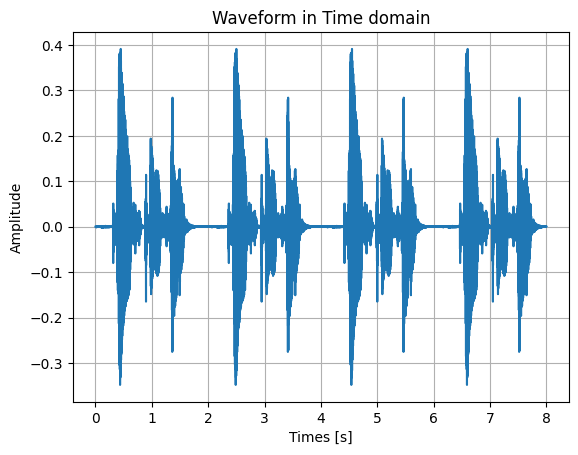

In [4]:
## Generate disturbance signal and reference signal
Dis, Fx, Ref = Disturbance_generation_from_real_noise(fs=fs, Repet=3, wave_from=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
Plot1 = WaveVisualizer(Dis,fs)
Plot1.plot_time_domain()

In [18]:
## Initialize the parameters
N = Dis.shape[0]
q = 0.00001
len = 512             
W = torch.zeros(len, 1, requires_grad=True, dtype=torch.float)
P = torch.eye(len, dtype=torch.float)
Xd = torch.zeros(len, 1, dtype=torch.float)             
ek = torch.zeros(N, dtype=torch.float) 

for ii in range(N):
    # Update input data vector
    Xd = torch.roll(Xd, 1)
    Xd[0] = Ref[ii]
    # Predict output based on current weights and input data
    yt = Xd.t() @ W
    # Call Kalman filter for ANC
    w_hat, P_pred, K, W, P = kalman_step(W, P, Xd, Dis[ii], q)
    # Calculate prediction error
    ek[ii] = Dis[ii] - yt
ek = ek.detach().numpy()

The SPL is -45.77 dB
The SPL is 56.86 dB


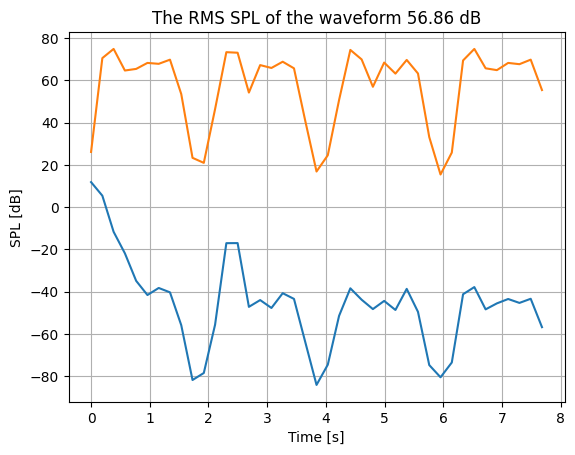

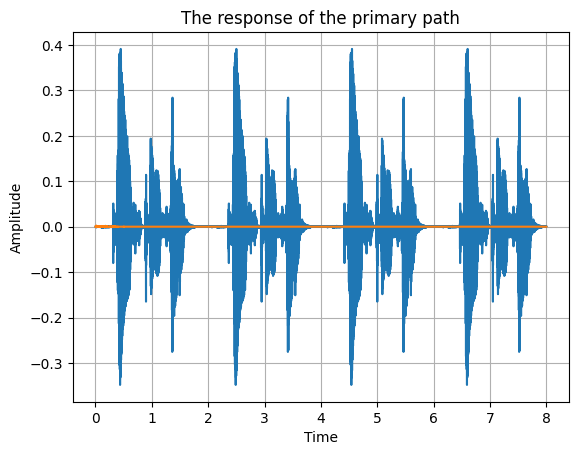

In [21]:
fig_error = WaveVisualizer(ek,16000)
fig_dis =  WaveVisualizer(Dis,16000)
fig_error.plot_RMS_SPL()
fig_dis.plot_RMS_SPL()
plt.figure()
plt.title('The response of the primary path')
Time = np.arange(Dis.shape[0])*(1/16000)
plt.plot(Time, Dis, Time, ek)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid()

In [ ]:
print( Dis.shape[0])